# Non Causal TF + Word2VEC 

In [75]:
import pandas as pd
import numpy as np
import pickle
import gensim.downloader as api
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

In [77]:
# 1. Load data
print("Loading datasets...")
X_train_df = pd.read_csv("X_train.csv")
X_val_df = pd.read_csv("X_val.csv")
y_train_raw = pd.read_csv("y_train.csv")["sentiment_consolidated"]
y_val_raw = pd.read_csv("y_val.csv")["sentiment_consolidated"]

print(f"Train samples: {len(X_train_df)}, Validation samples: {len(X_val_df)}")

# Merge for safe sampling (no leakage)
X_train_df["sentiment_consolidated"] = y_train_raw
X_val_df["sentiment_consolidated"] = y_val_raw

# Define sample sizes
TRAIN_SAMPLE_SIZE = 30000
VAL_SAMPLE_SIZE = 6000

# Stratified sampling to avoid data leakage
X_train_df, _ = train_test_split(
    X_train_df,
    train_size=TRAIN_SAMPLE_SIZE,
    stratify=X_train_df["sentiment_consolidated"],
    random_state=42
)

X_val_df, _ = train_test_split(
    X_val_df,
    train_size=VAL_SAMPLE_SIZE,
    stratify=X_val_df["sentiment_consolidated"],
    random_state=42
)

# Separate features and labels again
y_train_raw = X_train_df.pop("sentiment_consolidated")
y_val_raw   = X_val_df.pop("sentiment_consolidated")

print("Sampled Train size:", len(X_train_df))
print("Sampled Val size:", len(X_val_df))
print("Train label distribution:\n", y_train_raw.value_counts(normalize=True))
print("Val label distribution:\n", y_val_raw.value_counts(normalize=True))

Loading datasets...
Train samples: 535425, Validation samples: 88233
Sampled Train size: 30000
Sampled Val size: 6000
Train label distribution:
 sentiment_consolidated
negative    0.333333
positive    0.333333
neutral     0.333333
Name: proportion, dtype: float64
Val label distribution:
 sentiment_consolidated
positive    0.674333
negative    0.173500
neutral     0.152167
Name: proportion, dtype: float64


In [79]:

# 2. Load LabelEncoder
print("Loading label encoder...")
with open("label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

Loading label encoder...


C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [81]:
y_train = le.transform(y_train_raw)
y_val = le.transform(y_val_raw)
num_classes = len(le.classes_)
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)

print("Classes:", list(le.classes_))
print("Label distribution in train:", pd.Series(y_train).value_counts().to_dict())


Classes: ['negative', 'neutral', 'positive']
Label distribution in train: {0: 10000, 2: 10000, 1: 10000}


In [83]:
# 3. Load Word2Vec
print("Loading Word2Vec model...")
word2vec = api.load("word2vec-google-news-300")
embedding_dim = 300
max_len = 50


Loading Word2Vec model...


In [84]:
# 4. Convert tweets to Word2Vec embeddings
def text_to_embedding(texts, max_len=50):
    embeddings = []
    for i, text in enumerate(texts):
        tokens = str(text).split()
        vecs = [word2vec[word] for word in tokens if word in word2vec]
        if not vecs:
            vecs = [np.zeros(embedding_dim)]
        vecs = pad_sequences([vecs], maxlen=max_len, dtype='float32', padding='post', truncating='post')[0]
        embeddings.append(vecs)
        if i % 5000 == 0:  # Print progress
            print(f"Processed {i} samples...")
    return np.array(embeddings)

print("Converting training text to embeddings...")
X_train_embed = text_to_embedding(X_train_df["clean_tweet"], max_len)
print("Converting validation text to embeddings...")
X_val_embed = text_to_embedding(X_val_df["clean_tweet"], max_len)

print(f"Embedding shape (train): {X_train_embed.shape}")
print(f"Embedding shape (val):   {X_val_embed.shape}")

Converting training text to embeddings...
Processed 0 samples...
Processed 5000 samples...
Processed 10000 samples...
Processed 15000 samples...
Processed 20000 samples...
Processed 25000 samples...
Converting validation text to embeddings...
Processed 0 samples...
Processed 5000 samples...
Embedding shape (train): (30000, 50, 300)
Embedding shape (val):   (6000, 50, 300)


In [85]:
# 5. Create tf.data.Dataset for efficient parallel training
train_ds = tf.data.Dataset.from_tensor_slices((X_train_embed, y_train_cat)).shuffle(2048).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val_embed, y_val_cat)).batch(32).prefetch(tf.data.AUTOTUNE)


In [86]:
# 6. Define Transformer-based model
def build_transformer_model():
    inputs = Input(shape=(max_len, embedding_dim))
    x = LayerNormalization()(inputs)
    x = MultiHeadAttention(num_heads=2, key_dim=embedding_dim)(x, x)
    x = Dropout(0.2)(x)
    x = LayerNormalization()(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs)

model = build_transformer_model()
model.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 50, 300)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 300)   │        600 │ input_layer_8[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 300)   │    722,100 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 50, 300)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 300)   │        600 │ dropout_25[0][0]  │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 300)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 128)       │     38,528 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_26          │ (None, 128)       │          0 │ dense_16[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 3)         │        387 │ dropout_26[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 762,215 (2.91 MB)

 Trainable params: 762,215 (2.91 MB)

 Non-trainable params: 0 (0.00 B)

## Cross Validation

In [91]:
# Step 7: Cross-Validation Training
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import numpy as np
import time

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_accuracies = []
fold_aucs = []
best_score = 0
best_fold = None
best_report = ""
best_conf_matrix = None

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_embed, y_train)):
    print(f"\nFold {fold+1}")

    # Prepare data for this fold
    X_tr, X_val_cv = X_train_embed[train_idx], X_train_embed[val_idx]
    y_tr, y_val_cv = y_train_cat[train_idx], y_train_cat[val_idx]

    # Build and compile the model
    model = build_transformer_model()  # Use your final tuned model function
    model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss='categorical_crossentropy', metrics=['accuracy'])

    # Progress message
    print(f"Starting training for Fold {fold+1}...")
    start_time = time.time()

    # Train on fold with progress bar
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val_cv, y_val_cv),
        epochs=5,  # You can increase if needed
        batch_size=32,
        verbose=1  # Progress bar shown
    )

    print(f"Training time for Fold {fold+1}: {time.time() - start_time:.2f} seconds")

    # Evaluate
    y_val_cv_pred_proba = model.predict(X_val_cv)
    y_val_cv_pred = y_val_cv_pred_proba.argmax(axis=1)
    y_val_cv_true = y_val_cv.argmax(axis=1)

    acc = accuracy_score(y_val_cv_true, y_val_cv_pred)
    auc = roc_auc_score(y_val_cv_true, y_val_cv_pred_proba, multi_class='ovr', average='macro')
    fold_accuracies.append(acc)
    fold_aucs.append(auc)

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")
    print(f" Fold {fold+1} ROC AUC: {auc:.4f}")
    print("\n Classification Report:")
    print(classification_report(y_val_cv_true, y_val_cv_pred, target_names=le.classes_))
    print("\n Confusion Matrix:")
    print(confusion_matrix(y_val_cv_true, y_val_cv_pred))

    if acc > best_score:
        best_score = acc
        best_fold = fold + 1
        best_report = classification_report(y_val_cv_true, y_val_cv_pred, target_names=le.classes_)
        best_conf_matrix = confusion_matrix(y_val_cv_true, y_val_cv_pred)

# Summary after all folds
print("\n============================")
print("Cross-Validation Summary")
for i, acc in enumerate(fold_accuracies):
    print(f"Fold {i+1} Accuracy: {acc:.4f} | AUC: {fold_aucs[i]:.4f}")

print(f"\nBest Fold: {best_fold} | Accuracy: {best_score:.4f}")
print("\nAverage Accuracy: {:.4f} ± {:.4f}".format(np.mean(fold_accuracies), np.std(fold_accuracies)))
print("Average AUC: {:.4f} ± {:.4f}".format(np.mean(fold_aucs), np.std(fold_aucs)))

print("\nBest Classification Report:")
print(best_report)
print("\nBest Confusion Matrix:")
print(best_conf_matrix)



Fold 1
Starting training for Fold 1...
Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 85s 107ms/step - accuracy: 0.6284 - loss: 0.8282 - val_accuracy: 0.7148 - val_loss: 0.6746
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 80s 106ms/step - accuracy: 0.7274 - loss: 0.6577 - val_accuracy: 0.7232 - val_loss: 0.6503
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 107ms/step - accuracy: 0.7328 - loss: 0.6394 - val_accuracy: 0.7323 - val_loss: 0.6365
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 107ms/step - accuracy: 0.7462 - loss: 0.6174 - val_accuracy: 0.7330 - val_loss: 0.6336
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 79s 106ms/step - accuracy: 0.7562 - loss: 0.5939 - val_accuracy: 0.7297 - val_loss: 0.6448
Training time for Fold 1: 406.71 seconds
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step
Fold 1 Accuracy: 0.7297
 Fold 1 ROC AUC: 0.8891

 Classification Report:
              precision    recall  f1-score   support

    negative       0.81      0.64      0.72      2000
     neutral       0.65      0.68      0.66  

In [92]:
# 8. Train model
print("Training model...")
import time
from tensorflow.keras.callbacks import EarlyStopping

print("Training model...")

# Define early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

# Start timer
start_time = time.time()

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop],
    verbose=1  # Shows progress bar
)

# End timer
elapsed_time = time.time() - start_time
print(f"⏱️ Total training time: {elapsed_time:.2f} seconds")



Training model...
Training model...
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 128s 129ms/step - accuracy: 0.7591 - loss: 0.5966 - val_accuracy: 0.8042 - val_loss: 0.5440
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 113s 121ms/step - accuracy: 0.7644 - loss: 0.5781 - val_accuracy: 0.8100 - val_loss: 0.5193
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 107s 114ms/step - accuracy: 0.7690 - loss: 0.5668 - val_accuracy: 0.7750 - val_loss: 0.5953
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 115s 122ms/step - accuracy: 0.7748 - loss: 0.5547 - val_accuracy: 0.8053 - val_loss: 0.5430
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 2.
⏱️ Total training time: 463.58 seconds


In [17]:
# Step 8: Save the trained model
model.save("transformer_sentiment_model.h5")
print("Model saved to 'transformer_sentiment_model.h5'")


Model saved to 'transformer_sentiment_model.h5'


## Classification Report

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np

# Predict on validation set
y_val_pred_proba = model.predict(X_val_embed, batch_size=32)
y_val_pred = np.argmax(y_val_pred_proba, axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=le.classes_))

# ROC AUC (macro)
if num_classes > 2:
    y_val_bin = to_categorical(y_val, num_classes)
    auc_score = roc_auc_score(y_val_bin, y_val_pred_proba, average="macro", multi_class="ovr")
else:
    auc_score = roc_auc_score(y_val, y_val_pred_proba[:, 1])
print(f"\nROC AUC Score (macro): {auc_score:.4f}")


188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step

Classification Report:
              precision    recall  f1-score   support

    negative       0.70      0.72      0.71      1041
     neutral       0.56      0.61      0.59       913
    positive       0.92      0.90      0.91      4046

    accuracy                           0.82      6000
   macro avg       0.73      0.74      0.74      6000
weighted avg       0.83      0.82      0.83      6000


ROC AUC Score (macro): 0.9145


## Confusion Matrix

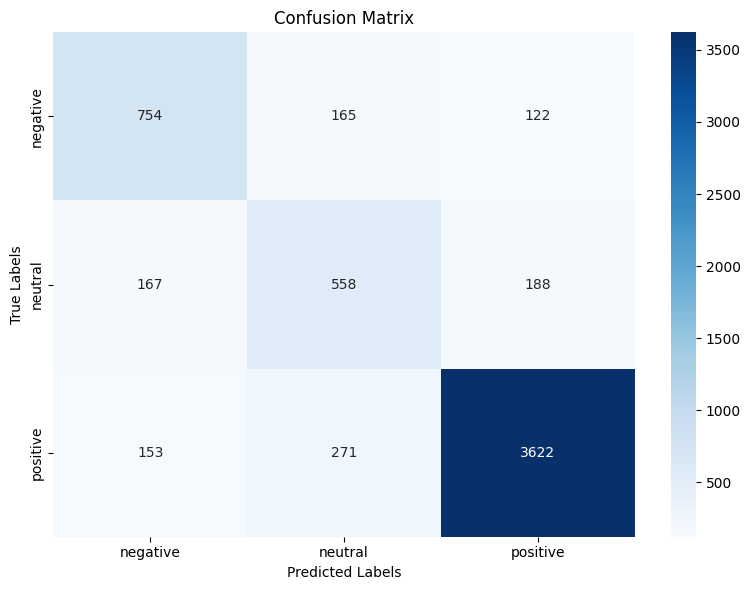

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_val, y_val_pred)

# Plot it
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


In [22]:
# Save predictions to CSV
val_predictions_df = pd.DataFrame({
    "original_text": X_val_df["clean_tweet"],
    "true_label": le.inverse_transform(y_val),
    "predicted_label": le.inverse_transform(y_val_pred)
})
val_predictions_df.to_csv("val_predictions.csv", index=False)
print("Saved predictions to 'val_predictions.csv'")


Saved predictions to 'val_predictions.csv'


##  Train vs Validation Accuracy

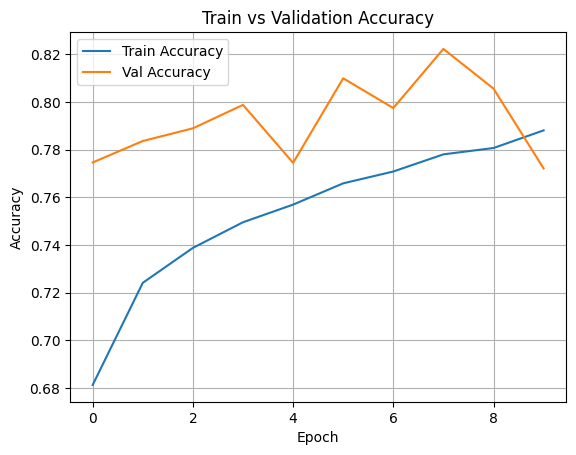

In [24]:
# Overfitting Check: Train vs Validation Accuracy
import matplotlib.pyplot as plt

# Plot train/val accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [25]:
#  Performance Across Classes
from sklearn.metrics import classification_report

print("Performance across classes:\n")
print(classification_report(y_val, y_val_pred, target_names=le.classes_))


Performance across classes:

              precision    recall  f1-score   support

    negative       0.70      0.72      0.71      1041
     neutral       0.56      0.61      0.59       913
    positive       0.92      0.90      0.91      4046

    accuracy                           0.82      6000
   macro avg       0.73      0.74      0.74      6000
weighted avg       0.83      0.82      0.83      6000



In [26]:
# AUC vs Accuracy
from sklearn.metrics import accuracy_score, roc_auc_score

val_accuracy = accuracy_score(y_val, y_val_pred)
if num_classes > 2:
    y_val_bin = to_categorical(y_val, num_classes)
    val_auc = roc_auc_score(y_val_bin, y_val_pred_proba, average="macro", multi_class="ovr")
else:
    val_auc = roc_auc_score(y_val, y_val_pred_proba[:, 1])

print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation AUC Score: {val_auc:.4f}")


Validation Accuracy: 0.8223
Validation AUC Score: 0.9145


In [27]:
# Performance Across Tweet Lengths
X_val_df["text_len"] = X_val_df["clean_tweet"].str.split().apply(len)
X_val_df["true_label"] = y_val
X_val_df["pred_label"] = y_val_pred

bins = [0, 5, 10, 15, 25, 50, 100]
X_val_df["length_bin"] = pd.cut(X_val_df["text_len"], bins)

print("Accuracy across tweet length bins:")
print(X_val_df.groupby("length_bin").apply(lambda df: (df["true_label"] == df["pred_label"]).mean()))


Accuracy across tweet length bins:
length_bin
(0, 5]       0.902954
(5, 10]      0.876712
(10, 15]     0.824219
(15, 25]     0.753061
(25, 50]     0.783198
(50, 100]    0.000000
dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_15052\44100841.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(X_val_df.groupby("length_bin").apply(lambda df: (df["true_label"] == df["pred_label"]).mean()))
C:\Users\Dell\AppData\Local\Temp\ipykernel_15052\44100841.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(X_val_df.groupby("length_bin").apply(lambda df: (df["true_label"] == df["pred_label"]).mean()))


In [28]:
!pip install emoji

In [29]:
# Performance With/Without Emojis
import emoji

def contains_emoji(text):
    return any(char in emoji.EMOJI_DATA for char in text)

X_val_df["has_emoji"] = X_val_df["clean_tweet"].apply(contains_emoji)

print("Accuracy with emojis:", (X_val_df[X_val_df["has_emoji"]]["true_label"] == X_val_df[X_val_df["has_emoji"]]["pred_label"]).mean())
print("Accuracy without emojis:", (X_val_df[~X_val_df["has_emoji"]]["true_label"] == X_val_df[~X_val_df["has_emoji"]]["pred_label"]).mean())


Accuracy with emojis: nan
Accuracy without emojis: 0.8223333333333334


In [30]:
# Performance With/Without Hashtags
X_val_df["has_hashtag"] = X_val_df["clean_tweet"].str.contains("#")

print("Accuracy with hashtags:", (X_val_df[X_val_df["has_hashtag"]]["true_label"] == X_val_df[X_val_df["has_hashtag"]]["pred_label"]).mean())
print("Accuracy without hashtags:", (X_val_df[~X_val_df["has_hashtag"]]["true_label"] == X_val_df[~X_val_df["has_hashtag"]]["pred_label"]).mean())


Accuracy with hashtags: nan
Accuracy without hashtags: 0.8223333333333334


In [31]:
#  Interpretability: Check if "parks" is Top Positive Feature
from collections import Counter

positive_indices = np.where(y_val_pred == le.transform(["positive"])[0])[0]
positive_words = " ".join(X_val_df.iloc[positive_indices]["clean_tweet"]).split()
top_positive_words = Counter(positive_words).most_common(20)

print("Top 20 words in predicted positive tweets:")
print(top_positive_words)



Top 20 words in predicted positive tweets:
[('freedom', 3930), ('convoy', 3700), ('ottawa', 537), ('trucker', 515), ('canadian', 502), ('via', 471), ('canada', 457), ('people', 317), ('protest', 305), ('amp', 283), ('like', 257), ('trudeau', 245), ('police', 231), ('support', 231), ('right', 219), ('live', 180), ('u', 167), ('government', 164), ('the_NEG', 158), ('mandate', 156)]


Final Training Accuracy:     0.7881
Final Validation Accuracy:   0.7722
Accuracy Gap:                0.0160
Final Training Loss:         0.5221
Final Validation Loss:       0.6320
Loss Gap:                    0.1099
🟢 Good Fit: Model generalizes well.


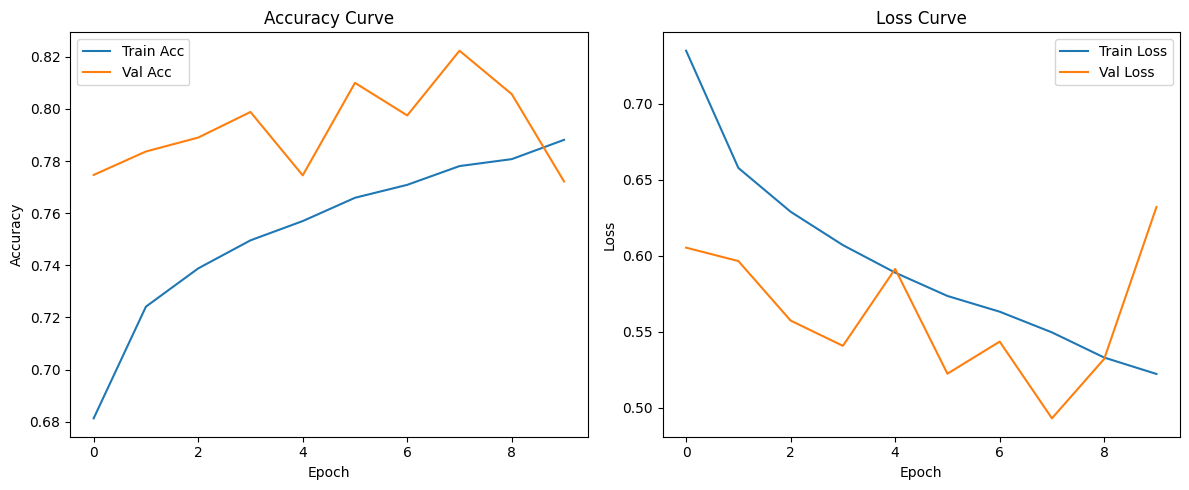

In [32]:
import numpy as np
import matplotlib.pyplot as plt

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Final epoch values
final_train_acc = train_acc[-1]
final_val_acc = val_acc[-1]
final_train_loss = train_loss[-1]
final_val_loss = val_loss[-1]

# Accuracy gap
acc_gap = final_train_acc - final_val_acc
loss_gap = final_val_loss - final_train_loss

# Print summary
print(f"Final Training Accuracy:     {final_train_acc:.4f}")
print(f"Final Validation Accuracy:   {final_val_acc:.4f}")
print(f"Accuracy Gap:                {acc_gap:.4f}")
print(f"Final Training Loss:         {final_train_loss:.4f}")
print(f"Final Validation Loss:       {final_val_loss:.4f}")
print(f"Loss Gap:                    {loss_gap:.4f}")

# Diagnosis
if final_train_acc > 0.85 and acc_gap > 0.1:
    print("🔴 Likely Overfitting: Training acc high, validation lagging.")
elif final_train_acc < 0.7 and final_val_acc < 0.7:
    print("🟡 Likely Underfitting: Model fails to learn patterns.")
elif acc_gap < 0.05 and final_val_acc > 0.75:
    print("🟢 Good Fit: Model generalizes well.")
else:
    print("⚠️ Borderline: May need more data or tuning.")

# Optional: Plot loss and accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_acc, label='Train Acc')
plt.plot(val_acc, label='Val Acc')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


## Testing Data Check

Processed 0 samples...
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 82ms/step

📊 Test Classification Report:
              precision    recall  f1-score   support

    negative       0.62      0.74      0.68       868
     neutral       0.51      0.64      0.57       761
    positive       0.94      0.84      0.89      3371

    accuracy                           0.79      5000
   macro avg       0.69      0.74      0.71      5000
weighted avg       0.82      0.79      0.80      5000


🧩 Test Confusion Matrix:
[[ 645  157   66]
 [ 158  486  117]
 [ 237  304 2830]]

✅ Test Accuracy: 0.7922
🎯 Test ROC AUC Score (macro): 0.9105


C:\Users\Dell\AppData\Local\Temp\ipykernel_15052\3699525947.py:70: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from current font.
  plt.tight_layout()
C:\Users\Dell\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


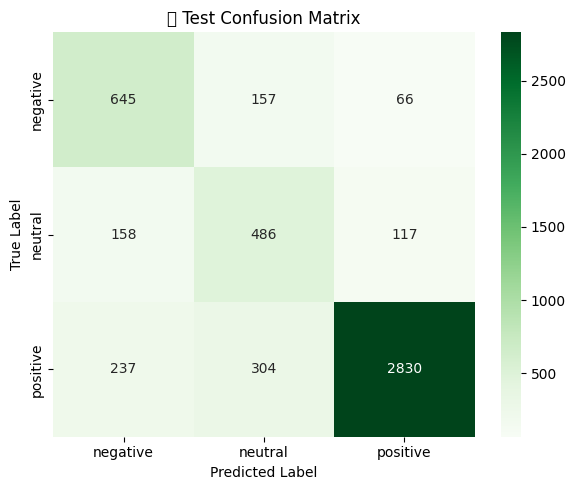

In [66]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns
# ---------- Step 1: Load and Sample Test Set ----------
X_test_df = pd.read_csv("X_test.csv")
y_test_raw = pd.read_csv("y_test.csv")["sentiment_consolidated"]

# Merge to allow stratified sampling
X_test_df["sentiment"] = y_test_raw
TEST_SAMPLE_SIZE = 5000

X_test_df_sampled, _ = train_test_split(
    X_test_df,
    train_size=TEST_SAMPLE_SIZE,
    stratify=X_test_df["sentiment"],
    random_state=42
)

y_test_raw = X_test_df_sampled.pop("sentiment")

# ---------- Step 2: Encode Labels ----------
# Reuse the existing LabelEncoder if already loaded earlier
# If not:
# with open("label_encoder.pkl", "rb") as f:
#     le = pickle.load(f)

y_test = le.transform(y_test_raw)
num_classes = len(le.classes_)
y_test_cat = to_categorical(y_test, num_classes)

# ---------- Step 3: Word2Vec Embedding ----------
X_test_embed = text_to_embedding(X_test_df_sampled["clean_tweet"], max_len)

# ---------- Step 4: Predict on Test Set ----------
y_test_pred_proba = model.predict(X_test_embed, batch_size=32)
y_test_pred = y_test_pred_proba.argmax(axis=1)

# ---------- Step 5: Text Evaluation Outputs ----------
print("\n📊 Test Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print("\n🧩 Test Confusion Matrix:")
print(cm)

# Accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"\n✅ Test Accuracy: {test_accuracy:.4f}")

# ROC AUC Score
if num_classes > 2:
    y_test_bin = to_categorical(y_test, num_classes)
    test_auc = roc_auc_score(y_test_bin, y_test_pred_proba, average="macro", multi_class="ovr")
else:
    test_auc = roc_auc_score(y_test, y_test_pred_proba[:, 1])
print(f"🎯 Test ROC AUC Score (macro): {test_auc:.4f}")

# ---------- Step 6: Plot Confusion Matrix ----------
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("🧩 Test Confusion Matrix")
plt.tight_layout()
plt.show()


## 1st Round Empricial Tunning

In [34]:
def build_tuned_transformer():
    inputs = Input(shape=(max_len, embedding_dim))
    
    # Normalize input
    x = LayerNormalization()(inputs)
    
    # Multi-head Attention with slightly higher heads
    attn = MultiHeadAttention(num_heads=4, key_dim=embedding_dim)(x, x)
    x = Dropout(0.25)(attn)  # Reduced dropout
    
    # Layer Norm again
    x = LayerNormalization()(x)
    
    # Global Average Pooling and Dense Layers
    x = GlobalAveragePooling1D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    
    outputs = Dense(num_classes, activation='softmax')(x)
    
    return Model(inputs, outputs)

model = build_tuned_transformer()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])


In [35]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 170s 177ms/step - accuracy: 0.6355 - loss: 0.8089 - val_accuracy: 0.7933 - val_loss: 0.5813 - learning_rate: 1.0000e-04
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 164s 175ms/step - accuracy: 0.7179 - loss: 0.6675 - val_accuracy: 0.8010 - val_loss: 0.5505 - learning_rate: 1.0000e-04
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 173s 184ms/step - accuracy: 0.7315 - loss: 0.6395 - val_accuracy: 0.7947 - val_loss: 0.5575 - learning_rate: 1.0000e-04
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 208s 221ms/step - accuracy: 0.7484 - loss: 0.6089 - val_accuracy: 0.8033 - val_loss: 0.5361 - learning_rate: 1.0000e-04
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 209s 223ms/step - accuracy: 0.7592 - loss: 0.5851 - val_accuracy: 0.8062 - val_loss: 0.5221 - learning_rate: 1.0000e-04
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 231s 246ms/step - accuracy: 0.7681 - loss: 0.5707 - val_accuracy: 0.7768 - val_loss: 0.6302 - learning_rate: 1.0000e-04
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 

In [36]:
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=1e-4, clipnorm=1.0)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])


In [37]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from collections import Counter
import emoji

# ---------- Make Predictions ----------
print("Generating predictions...")
y_val_pred_proba = model.predict(X_val_embed, batch_size=32)
y_val_pred = np.argmax(y_val_pred_proba, axis=1)

# ---------- Accuracy and AUC ----------
val_accuracy = accuracy_score(y_val, y_val_pred)

if num_classes > 2:
    y_val_bin = to_categorical(y_val, num_classes)
    val_auc = roc_auc_score(y_val_bin, y_val_pred_proba, average="macro", multi_class="ovr")
else:
    val_auc = roc_auc_score(y_val, y_val_pred_proba[:, 1])

print(f"\n✅ Validation Accuracy: {val_accuracy:.4f}")
print(f"✅ ROC AUC Score (macro): {val_auc:.4f}")

# ---------- Classification Report ----------
print("\n📊 Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=le.classes_))

Generating predictions...
188/188 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step

✅ Validation Accuracy: 0.8062
✅ ROC AUC Score (macro): 0.9138

📊 Classification Report:
              precision    recall  f1-score   support

    negative       0.73      0.68      0.70      1041
     neutral       0.49      0.67      0.57       913
    positive       0.93      0.87      0.90      4046

    accuracy                           0.81      6000
   macro avg       0.72      0.74      0.72      6000
weighted avg       0.83      0.81      0.81      6000



## Confusion Matrix

C:\Users\Dell\AppData\Local\Temp\ipykernel_15052\3973376967.py:16: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from current font.
  plt.tight_layout()
C:\Users\Dell\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


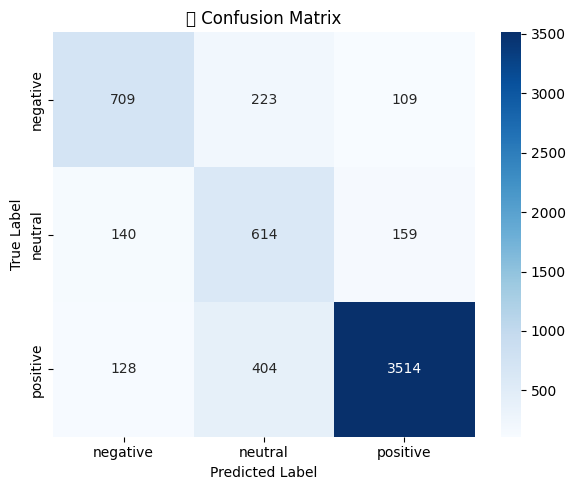

In [39]:
# ---------- Confusion Matrix ----------
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
class_names = le.classes_

# Plot it
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("🧩 Confusion Matrix")
plt.tight_layout()
plt.show()


In [40]:
# ---------- Tweet Length Analysis ----------
X_val_df["text_len"] = X_val_df["clean_tweet"].str.split().apply(len)
X_val_df["true_label"] = y_val
X_val_df["pred_label"] = y_val_pred

bins = [0, 5, 10, 15, 25, 50, 100]
X_val_df["length_bin"] = pd.cut(X_val_df["text_len"], bins)

print("\n📏 Accuracy by Tweet Length:")
print(X_val_df.groupby("length_bin").apply(lambda df: (df["true_label"] == df["pred_label"]).mean()))




📏 Accuracy by Tweet Length:
length_bin
(0, 5]       0.895921
(5, 10]      0.861227
(10, 15]     0.806250
(15, 25]     0.730612
(25, 50]     0.783198
(50, 100]    1.000000
dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_15052\445400314.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(X_val_df.groupby("length_bin").apply(lambda df: (df["true_label"] == df["pred_label"]).mean()))
C:\Users\Dell\AppData\Local\Temp\ipykernel_15052\445400314.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(X_val_df.groupby("length_bin").apply(lambda df: (df["true_label"] == df["pred_label"]).mean()))


In [41]:
# ---------- Emoji Analysis ----------
def contains_emoji(text):
    return any(char in emoji.EMOJI_DATA for char in text)

X_val_df["has_emoji"] = X_val_df["clean_tweet"].apply(contains_emoji)

print("\n😀 Emoji Performance:")
print("With emojis accuracy:", (X_val_df[X_val_df["has_emoji"]]["true_label"] == X_val_df[X_val_df["has_emoji"]]["pred_label"]).mean())
print("Without emojis accuracy:", (X_val_df[~X_val_df["has_emoji"]]["true_label"] == X_val_df[~X_val_df["has_emoji"]]["pred_label"]).mean())


😀 Emoji Performance:
With emojis accuracy: nan
Without emojis accuracy: 0.8061666666666667


In [42]:
# ---------- Hashtag Analysis ----------
X_val_df["has_hashtag"] = X_val_df["clean_tweet"].str.contains("#")

print("\n#️⃣ Hashtag Performance:")
print("With hashtags accuracy:", (X_val_df[X_val_df["has_hashtag"]]["true_label"] == X_val_df[X_val_df["has_hashtag"]]["pred_label"]).mean())
print("Without hashtags accuracy:", (X_val_df[~X_val_df["has_hashtag"]]["true_label"] == X_val_df[~X_val_df["has_hashtag"]]["pred_label"]).mean())


#️⃣ Hashtag Performance:
With hashtags accuracy: nan
Without hashtags accuracy: 0.8061666666666667


In [43]:
# ---------- Top Words in Positive Predictions ----------
positive_indices = np.where(y_val_pred == le.transform(["positive"])[0])[0]
positive_words = " ".join(X_val_df.iloc[positive_indices]["clean_tweet"]).split()
top_positive_words = Counter(positive_words).most_common(20)

print("\n💬 Top 20 Words in Predicted Positive Tweets:")
for word, freq in top_positive_words:
    print(f"{word}: {freq}")


💬 Top 20 Words in Predicted Positive Tweets:
freedom: 3801
convoy: 3576
ottawa: 529
trucker: 505
canadian: 488
via: 465
canada: 445
people: 308
protest: 296
amp: 269
like: 243
trudeau: 233
support: 231
police: 223
right: 204
live: 181
u: 163
government: 157
mandate: 150
the_NEG: 150


## Accuracy & Loss Curves

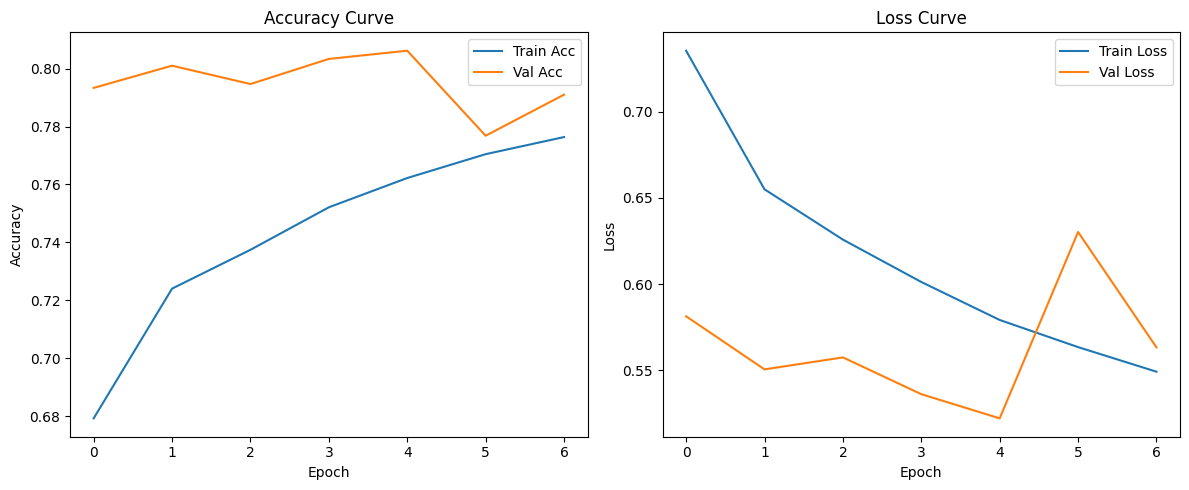

In [45]:
# Accuracy & Loss Curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


# 2nd Round Empirical Tunning

In [47]:
# Step 1: Define new Transformer model with modified hyperparameters
def build_second_tuned_transformer():
    inputs = Input(shape=(max_len, embedding_dim))
    
    # Layer Normalization
    x = LayerNormalization()(inputs)
    
    # Multi-head Attention with more heads
    attn = MultiHeadAttention(num_heads=6, key_dim=embedding_dim)(x, x)
    x = Dropout(0.2)(attn)  # slightly reduced dropout
    
    # Post-attention normalization
    x = LayerNormalization()(x)
    
    # Pooling and Dense layer
    x = GlobalAveragePooling1D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.35)(x)  # increased dropout
    
    # Output layer
    outputs = Dense(num_classes, activation='softmax')(x)
    
    return Model(inputs, outputs)


In [48]:
# Step 2: Compile model with a different optimizer setting
from tensorflow.keras.optimizers import Adam

optimizer = Adam(learning_rate=5e-5, clipnorm=2.0)

model = build_second_tuned_transformer()
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 50, 300)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 300)   │        600 │ input_layer_2[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 300)   │  2,165,700 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 50, 300)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 300)   │        600 │ dropout_7[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 300)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     77,056 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 256)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 3)         │        771 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,244,727 (8.56 MB)

 Trainable params: 2,244,727 (8.56 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# Step 3: Train model with early stopping to prevent overfitting
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train_embed, y_train_cat,
    validation_data=(X_val_embed, y_val_cat),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 250s 517ms/step - accuracy: 0.6190 - loss: 0.8420 - val_accuracy: 0.7900 - val_loss: 0.5699
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 237s 506ms/step - accuracy: 0.7153 - loss: 0.6684 - val_accuracy: 0.7550 - val_loss: 0.6303
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 247s 527ms/step - accuracy: 0.7362 - loss: 0.6343 - val_accuracy: 0.7450 - val_loss: 0.6445
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 255s 544ms/step - accuracy: 0.7443 - loss: 0.6092 - val_accuracy: 0.8075 - val_loss: 0.5097
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 255s 543ms/step - accuracy: 0.7561 - loss: 0.6003 - val_accuracy: 0.7742 - val_loss: 0.5811
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 259s 553ms/step - accuracy: 0.7626 - loss: 0.5735 - val_accuracy: 0.8028 - val_loss: 0.5330
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 286s 610ms/step - accuracy: 0.7707 - loss: 0.5675 - val_accuracy: 0.8008 - val_loss: 0.5241


In [50]:
# Step 4: Evaluate model performance
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from tensorflow.keras.utils import to_categorical
import numpy as np

print("Generating predictions...")
y_val_pred_proba = model.predict(X_val_embed, batch_size=32)
y_val_pred = np.argmax(y_val_pred_proba, axis=1)

# Accuracy and AUC
val_accuracy = accuracy_score(y_val, y_val_pred)

if num_classes > 2:
    y_val_bin = to_categorical(y_val, num_classes)
    val_auc = roc_auc_score(y_val_bin, y_val_pred_proba, average="macro", multi_class="ovr")
else:
    val_auc = roc_auc_score(y_val, y_val_pred_proba[:, 1])

print(f"\n✅ Validation Accuracy (Round 2): {val_accuracy:.4f}")
print(f"✅ ROC AUC Score (macro) (Round 2): {val_auc:.4f}")

# Classification Report
print("\n📊 Classification Report (Round 2):")
print(classification_report(y_val, y_val_pred, target_names=le.classes_))

Generating predictions...
188/188 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step

✅ Validation Accuracy (Round 2): 0.8075
✅ ROC AUC Score (macro) (Round 2): 0.9088

📊 Classification Report (Round 2):
              precision    recall  f1-score   support

    negative       0.73      0.66      0.69      1041
     neutral       0.50      0.64      0.56       913
    positive       0.92      0.88      0.90      4046

    accuracy                           0.81      6000
   macro avg       0.72      0.73      0.72      6000
weighted avg       0.82      0.81      0.81      6000




🧩 Confusion Matrix (Round 2):


C:\Users\Dell\AppData\Local\Temp\ipykernel_15052\3039740833.py:16: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from current font.
  plt.tight_layout()
C:\Users\Dell\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


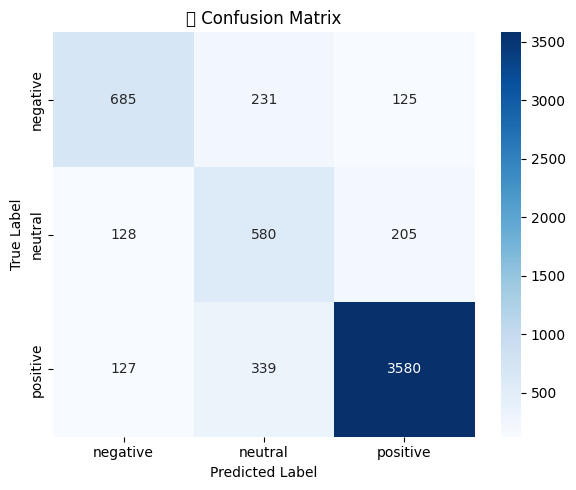

In [51]:
# ---------- Confusion Matrix ----------
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
print("\n🧩 Confusion Matrix (Round 2):")
# Compute confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
class_names = le.classes_

# Plot it
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("🧩 Confusion Matrix")
plt.tight_layout()
plt.show()

In [52]:
# ---------- Emoji Analysis ----------
def contains_emoji(text):
    return any(char in emoji.EMOJI_DATA for char in text)

X_val_df["has_emoji"] = X_val_df["clean_tweet"].apply(contains_emoji)

print("\n😀 Emoji Performance:")
print("With emojis accuracy:", (X_val_df[X_val_df["has_emoji"]]["true_label"] == X_val_df[X_val_df["has_emoji"]]["pred_label"]).mean())
print("Without emojis accuracy:", (X_val_df[~X_val_df["has_emoji"]]["true_label"] == X_val_df[~X_val_df["has_emoji"]]["pred_label"]).mean())


😀 Emoji Performance:
With emojis accuracy: nan
Without emojis accuracy: 0.8061666666666667


In [53]:
# ---------- Tweet Length Analysis ----------
X_val_df["text_len"] = X_val_df["clean_tweet"].str.split().apply(len)
X_val_df["true_label"] = y_val
X_val_df["pred_label"] = y_val_pred

bins = [0, 5, 10, 15, 25, 50, 100]
X_val_df["length_bin"] = pd.cut(X_val_df["text_len"], bins)

print("\n📏 Accuracy by Tweet Length:")
print(X_val_df.groupby("length_bin").apply(lambda df: (df["true_label"] == df["pred_label"]).mean()))




📏 Accuracy by Tweet Length:
length_bin
(0, 5]       0.879044
(5, 10]      0.864205
(10, 15]     0.807813
(15, 25]     0.737245
(25, 50]     0.783198
(50, 100]    1.000000
dtype: float64


C:\Users\Dell\AppData\Local\Temp\ipykernel_15052\445400314.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(X_val_df.groupby("length_bin").apply(lambda df: (df["true_label"] == df["pred_label"]).mean()))
C:\Users\Dell\AppData\Local\Temp\ipykernel_15052\445400314.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(X_val_df.groupby("length_bin").apply(lambda df: (df["true_label"] == df["pred_label"]).mean()))


In [54]:
# ---------- Hashtag Analysis ----------
X_val_df["has_hashtag"] = X_val_df["clean_tweet"].str.contains("#")

print("\n#️⃣ Hashtag Performance:")
print("With hashtags accuracy:", (X_val_df[X_val_df["has_hashtag"]]["true_label"] == X_val_df[X_val_df["has_hashtag"]]["pred_label"]).mean())
print("Without hashtags accuracy:", (X_val_df[~X_val_df["has_hashtag"]]["true_label"] == X_val_df[~X_val_df["has_hashtag"]]["pred_label"]).mean())


#️⃣ Hashtag Performance:
With hashtags accuracy: nan
Without hashtags accuracy: 0.8075


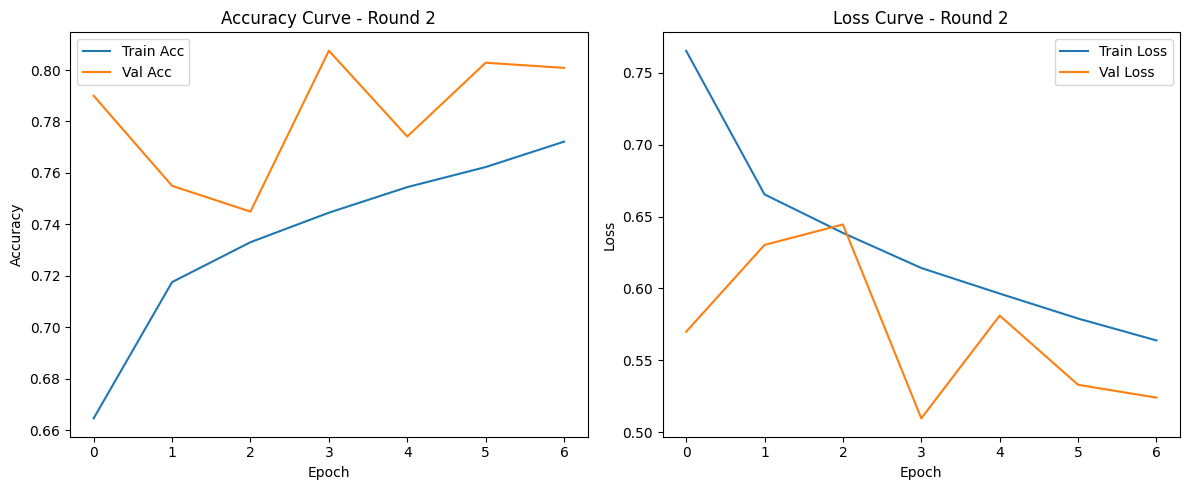

In [55]:
# Step 5: Plot training curves
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy Curve - Round 2")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve - Round 2")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
model.save("non-causalTF_Word2Vec_tuned_v2.h5")